In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False,
}

# keyword arguments for inspiral generator
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing TIME-MAXIMIZED loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.25 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5
phiS = 1
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# Explicit mode groups: ℓ∈{2,3}, n∈{-5,-4,-3,-2,-1}
# Group modes by n value, including all m for each (ℓ,n) pair
# captures ~70% of SNR
mega_mode_groups = [
    # Group 1: All ℓ=3, n=-5 AND ℓ=2, n=-5
    [(3, 0, -5), (3, 1, -5), (3, 2, -5), (3, 3, -5), (3, -1, -5), (3, -2, -5), (3, -3, -5),
     (2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)],

    # Group 2: All ℓ=3, n=-4 AND ℓ=2, n=-4
    [(3, 0, -4), (3, 1, -4), (3, 2, -4), (3, 3, -4), (3, -1, -4), (3, -2, -4), (3, -3, -4),
     (2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)],

    # Group 3: All ℓ=3, n=-3 AND ℓ=2, n=-3
    [(3, 0, -3), (3, 1, -3), (3, 2, -3), (3, 3, -3), (3, -1, -3), (3, -2, -3), (3, -3, -3),
     (2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)],

    # Group 4: All ℓ=3, n=-2 AND ℓ=2, n=-2
    [(3, 0, -2), (3, 1, -2), (3, 2, -2), (3, 3, -2), (3, -1, -2), (3, -2, -2), (3, -3, -2),
     (2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)],

    # Group 5: All ℓ=3, n=-1 AND ℓ=2, n=-1
    [(3, 0, -1), (3, 1, -1), (3, 2, -1), (3, 3, -1), (3, -1, -1), (3, -2, -1), (3, -3, -1),
     (2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)],
]

# OLD n-indexed mode selection parameters (commented out)
# n_vals = np.arange(-5, 0)  # n from -5 to -1
# ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using TIME-MAXIMIZED LogLike with explicit mode groups
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    mode_select=mega_mode_groups,  # Use explicit mode groups
    M_mode=None  # No SNR filtering, use all mode groups
    # OLD: ell=ell, n_vals=n_vals
)

print('Done initializing TIME-MAXIMIZED loglike class.')
print('Calculating TIME-MAXIMIZED SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat_timemax(data)  # TIME-MAXIMIZED SNR
print('TIME-MAXIMIZED SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


with open('cov_matrix_2yr.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

sigmas = np.sqrt(np.diag(cov_matrix))
print("2 year sigmas:", sigmas)
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike 

    return log_likes

def prior_transform(u):
    n=1000
    logm1lim = [param_true[0] - n*sigmas[0], param_true[0] + n*sigmas[0]]
    logm2lim = [param_true[1] - n*sigmas[1], param_true[1] + n*sigmas[1]]
    alim = [param_true[2] - n*sigmas[2], min(param_true[2] + n*sigmas[2], 0.999)]  # a must be <1
    p0lim = [param_true[3] - n*sigmas[3], param_true[3] + n*sigmas[3]]
    e0lim = [param_true[4] - n*sigmas[4], param_true[4] + n*sigmas[4]]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]


    return transformed



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing TIME-MAXIMIZED loglike class...
Done initializing TIME-MAXIMIZED loglike class.
Calculating TIME-MAXIMIZED SNR...
TIME-MAXIMIZED SNR calculated: 5.283339408229158
Setting up log_density and prior functions...
2 year sigmas: [8.47413325e-05 1.01378439e-04 3.49039352e-04 2.40285811e-03
 4.45624469e-05]
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_1mth_timemax/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
n=1000
param_ranges = [(param_true[0] - n*sigmas[0], param_true[0] + n*sigmas[0]),
                (param_true[1] - n*sigmas[1], param_true[1] + n*sigmas[1]),
                (param_true[2] - n*sigmas[2], min(param_true[2] + n*sigmas[2], 0.999)),
                (param_true[3] - n*sigmas[3], param_true[3] + n*sigmas[3]),
                (param_true[4] - n*sigmas[4], param_true[4] + n*sigmas[4])
                ]
param_ranges

[(5.915258667542183, 6.084741332457817),
 (1.37574281578245, 1.5784996936568747),
 (0.350960648396513, 0.999),
 (12.597141890166823, 17.40285810983318),
 (0.3554375531246144, 0.44456244687538565)]

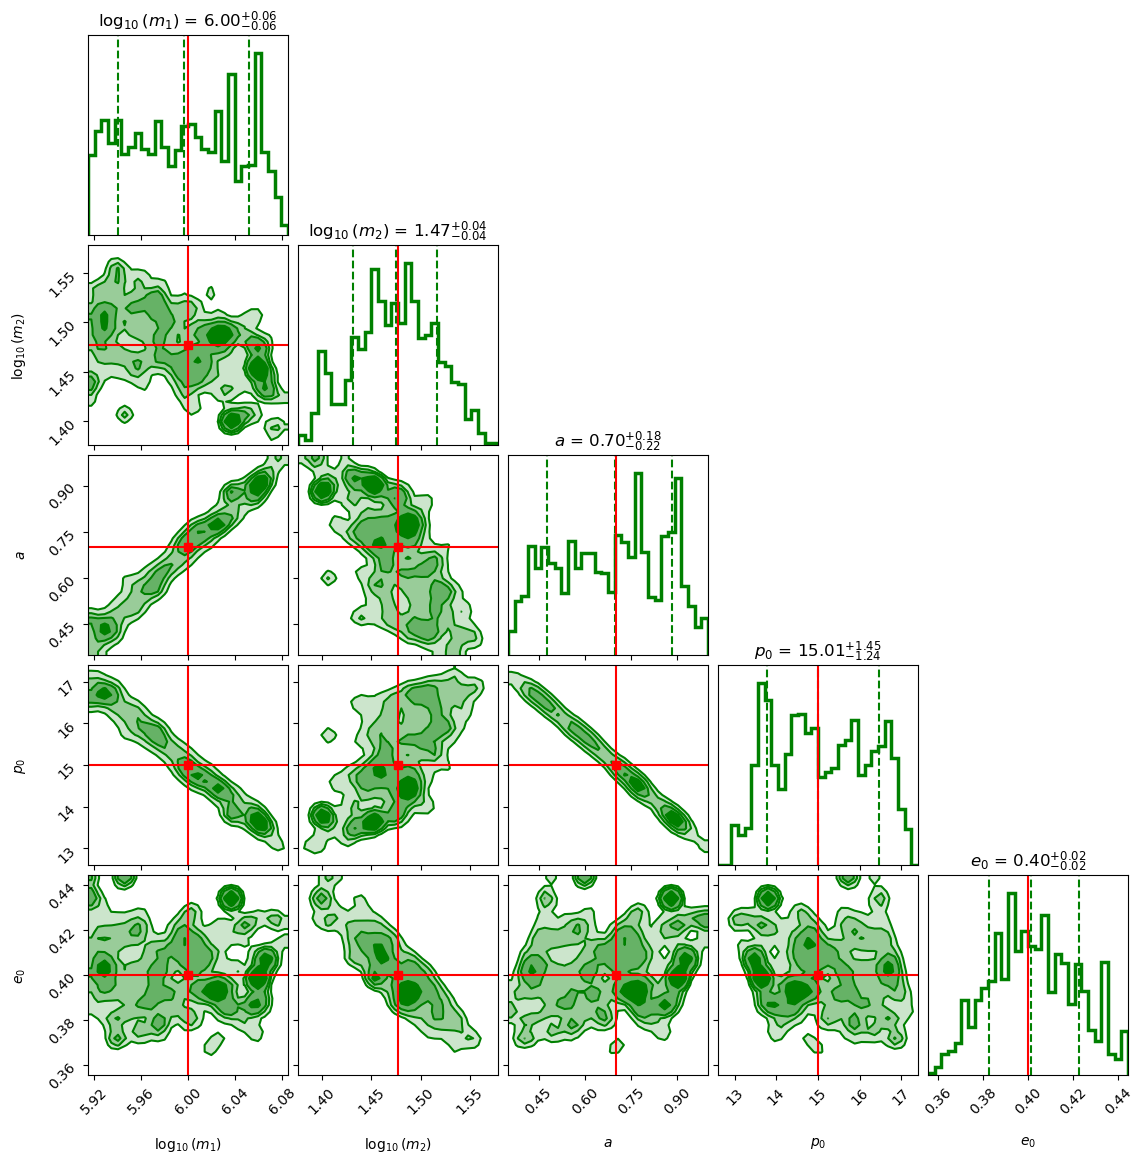

In [5]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

# corner.overplot_points(fig, proc1_maxld_pt.reshape(1, -1), 
#                        color='blue', marker='*', ms=10, 
#                        reverse=False)

# corner.overplot_points(fig, proc2_maxld_pt.reshape(1, -1), 
#                        color='orange', marker='*', ms=10,
#                        reverse=False)



In [6]:
proc1_maxld_pt = np.array([[ 6.02680358,  1.46982606,  0.7897165 , 14.39679547,  0.39827987]])
proc2_maxld_pt = np.array([[ 5.93845955,  1.50506177,  0.45790577, 16.56223858,  0.39802901]])

In [8]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0]  # Convert from (1,5) to (5,)
proc2_maxld_pt_1d = proc2_maxld_pt[0]  # Convert from (1,5) to (5,)
true_pt = np.array(param_true)


n_points = 100
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]
line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [9]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [10]:
logden_theory_proc2 = []
logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [11]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc2 = np.array(logden_theory_proc2).flatten()
logden_theory_proc1

array([5.27986793, 5.17815342, 5.11062959, 5.20632546, 5.16076071,
       4.99158401, 5.0444389 , 5.07320502, 4.9898626 , 4.81015467,
       4.87046531, 4.88066541, 4.81022101, 4.83200364, 4.87954036,
       4.85480389, 4.76523367, 4.88852161, 4.9755055 , 5.00397831,
       4.97865523, 4.90567543, 4.9121195 , 5.00479729, 5.05508781,
       5.06633865, 5.04503813, 4.99454718, 4.9181708 , 4.94158895,
       5.00431636, 5.04701993, 5.06650803, 5.06906504, 5.05682272,
       5.03218979, 4.99861791, 4.95861541, 4.91227006, 4.86663912,
       4.88952752, 4.92037345, 4.94310056, 4.95933213, 4.97099323,
       4.98114734, 4.98799961, 4.99236199, 4.99483653, 4.9957943 ,
       4.99536687, 4.99347605, 4.98981164, 4.98383105, 4.97477096,
       4.96343774, 4.94878621, 4.92807239, 4.89974675, 4.86450382,
       4.90223022, 4.94783975, 4.99005378, 5.02393266, 5.0526278 ,
       5.06683549, 5.07078002, 5.05548614, 5.02196636, 4.96651533,
       4.88666832, 4.9679157 , 5.02844002, 5.06192332, 5.06281

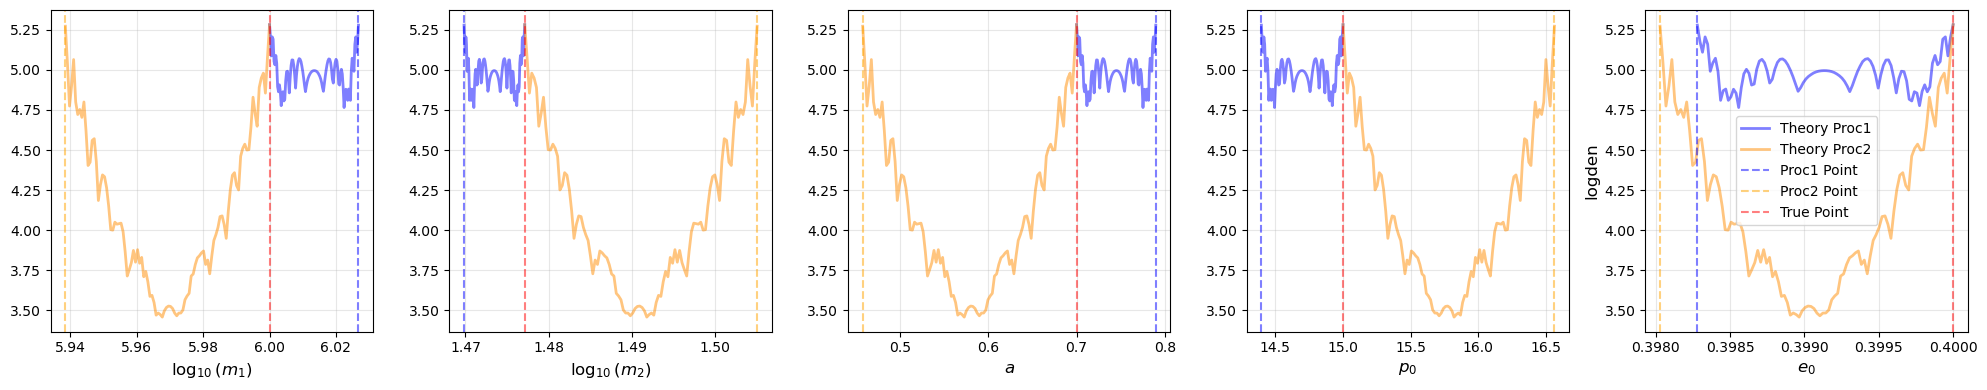

In [12]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Theory Proc1')
    ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
            color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Point')
    ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'Proc2 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
#     ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [13]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [14]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat(data, template)
    X_proc1.append(X.get())

In [15]:
templates_proc2 = []
for point in line_points_proc2.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc2.append(template)

In [18]:
X_proc2 = []
for template in templates_proc2:
    X = gwf.Xstat_timemax(data, template)
    X_proc2.append(X.get())

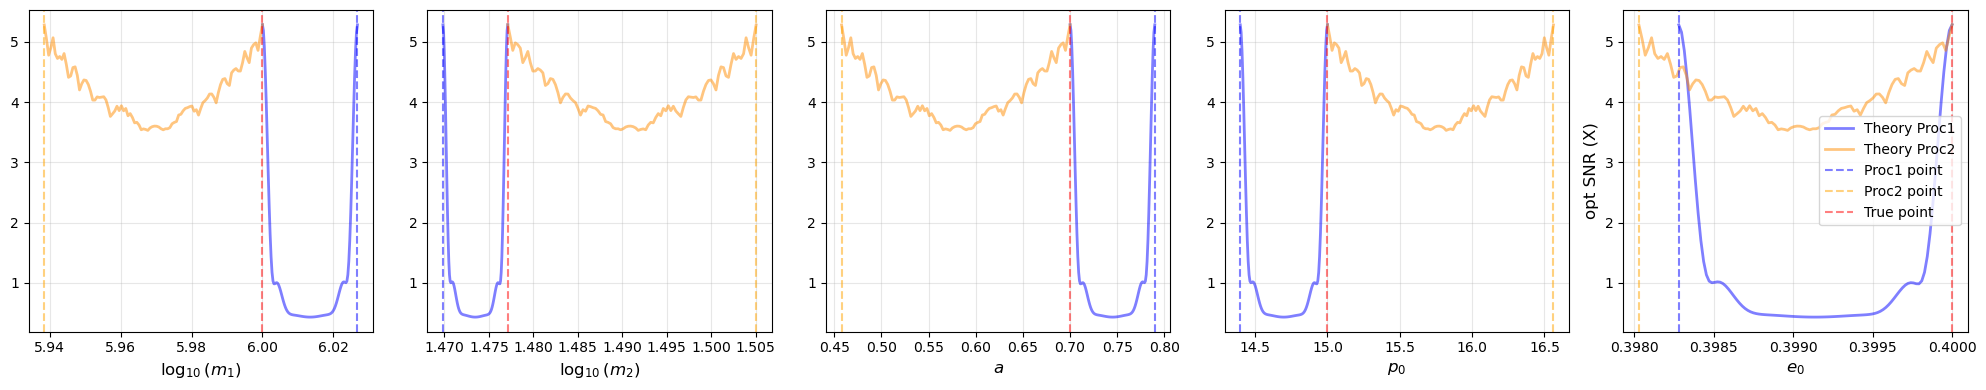

In [19]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Theory Proc1')
    ax.plot(line_points_proc2[dim], X_proc2, '-', 
            color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 point')
    ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:
mega_mode_groups

[[(3, 0, -5),
  (3, 1, -5),
  (3, 2, -5),
  (3, 3, -5),
  (3, -1, -5),
  (3, -2, -5),
  (3, -3, -5),
  (2, 0, -5),
  (2, 1, -5),
  (2, 2, -5),
  (2, -1, -5),
  (2, -2, -5)],
 [(3, 0, -4),
  (3, 1, -4),
  (3, 2, -4),
  (3, 3, -4),
  (3, -1, -4),
  (3, -2, -4),
  (3, -3, -4),
  (2, 0, -4),
  (2, 1, -4),
  (2, 2, -4),
  (2, -1, -4),
  (2, -2, -4)],
 [(3, 0, -3),
  (3, 1, -3),
  (3, 2, -3),
  (3, 3, -3),
  (3, -1, -3),
  (3, -2, -3),
  (3, -3, -3),
  (2, 0, -3),
  (2, 1, -3),
  (2, 2, -3),
  (2, -1, -3),
  (2, -2, -3)],
 [(3, 0, -2),
  (3, 1, -2),
  (3, 2, -2),
  (3, 3, -2),
  (3, -1, -2),
  (3, -2, -2),
  (3, -3, -2),
  (2, 0, -2),
  (2, 1, -2),
  (2, 2, -2),
  (2, -1, -2),
  (2, -2, -2)],
 [(3, 0, -1),
  (3, 1, -1),
  (3, 2, -1),
  (3, 3, -1),
  (3, -1, -1),
  (3, -2, -1),
  (3, -3, -1),
  (2, 0, -1),
  (2, 1, -1),
  (2, 2, -1),
  (2, -1, -1),
  (2, -2, -1)]]

In [58]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in mega_mode_groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [59]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [60]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [61]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

In [48]:
mode_forms_proc2 = []
for point in line_points_proc2.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each group
    waveforms_per_group = []
    for group in mega_mode_groups:
        mode_form_group = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass individual group
                                          include_minus_mkn=False)
        waveforms_per_group.append(mode_form_group)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    
    # Sort waveforms by index_map: hundreds ascending, then remainder descending
    # sorted_indices = sorted(range(len(mega_mode_groups)), 
    #                     key=lambda i: (amp.index_map[mega_mode_groups[i][0]] % 1000 // 100, 
    #                                         -(amp.index_map[mega_mode_groups[i][0]] % 100)))
    # mode_form = mode_form[:, sorted_indices] 
    mode_forms_proc2.append(mode_form)

In [49]:
rhostats_proc2 = []
for hm_arr in mode_forms_proc2:
    rhostats_proc2.append(gwf.rhostat_modes(hm_arr.T))

In [50]:
Xm_proc2 = []
for idx, hm_arr in enumerate(mode_forms_proc2):
    X_mode = gwf.Xmstat(data, hm_arr.T, rhostats_proc2[idx])
    Xm_proc2.append(X_mode)

In [51]:
chi2_proc2 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc2[i], rhostats_proc2[i])
    chi2_proc2.append(chi2.get())

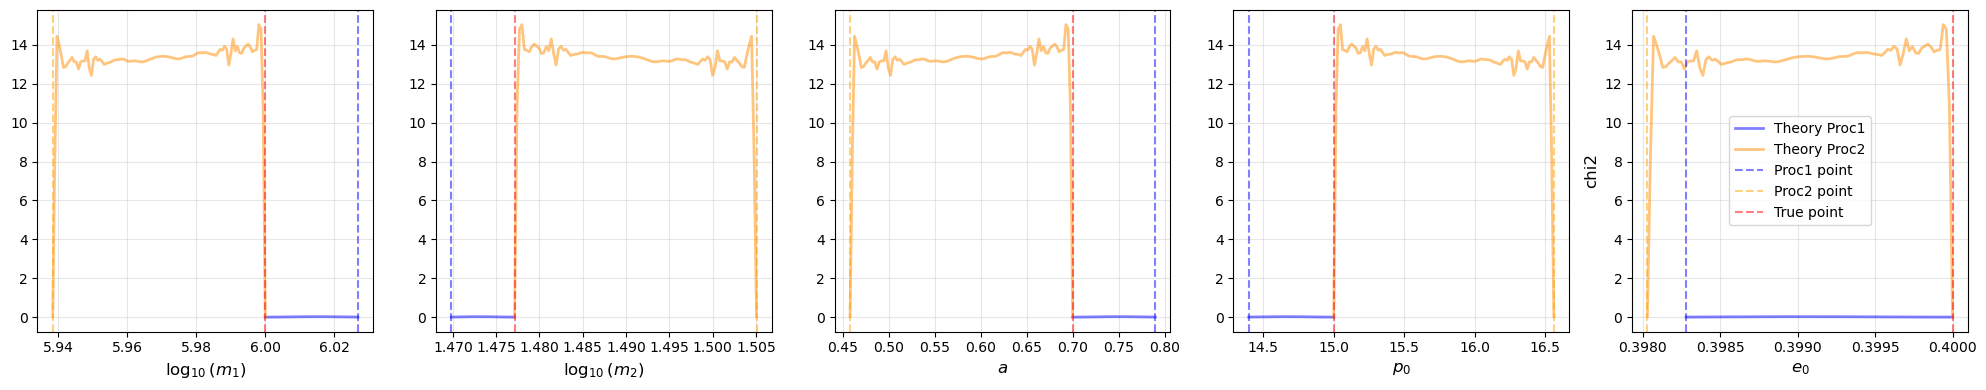

In [62]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Theory Proc1')
    ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
            color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 point')
    ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
               alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()
